In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm


from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable

import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature


from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [5]:
# open data
fig5 = xr.open_dataset("../preprocessed_data/fig5.nc")

d_composite = xr.Dataset({"sst": fig5["d_composite"]})
d_2023 = xr.Dataset({"sst": fig5["d_2023"]})

sstcomposite_aso = xr.Dataset({"sst": fig5["sstcomposite_aso"]})
sst2023_aso = xr.Dataset({"sst": fig5["sst2023_aso"]})

wcomposite_amjjas = xr.Dataset({"w": fig5["wcomposite_amjjas"]})
w2023_amjjas = xr.Dataset({"w": fig5["w2023_amjjas"]})

tp_composite = xr.Dataset({"tp": fig5["tp_composite"]})
tp_2023 = xr.Dataset({"tp": fig5["tp_2023"]})

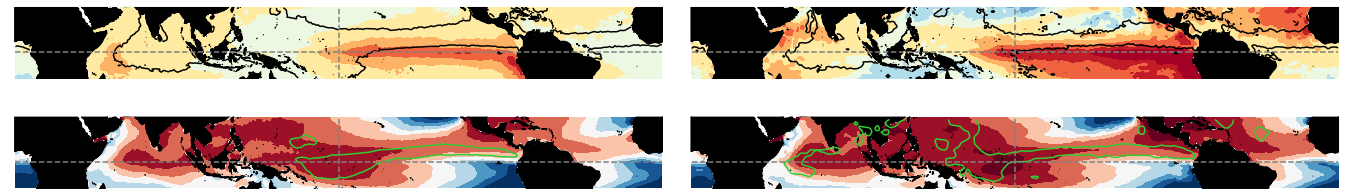

In [10]:
fp = '/home/jmex/Python_Notebooks/sea_mask.nc'
m = xr.open_dataset(fp)
# --- 0. Set up professional plotting parameters ---
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
    'lines.linewidth': 1.5,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.7,
    'savefig.dpi': 300,
    'savefig.format': 'svg',
})

lon, lat = d_composite.lon, d_composite.lat
aspect = (lat.max() - lat.min()) / (lon.max() - lon.min())

levels_d = np.linspace(-2, 2, 9)

# --- Create Figure and Gridspec ---
fig = plt.figure(figsize=(24, 4))
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.02, hspace=0.02)  # Tight control over spacing

# Define projection
projection = ccrs.PlateCarree(central_longitude=180)

# Create axes manually
ax0 = fig.add_subplot(gs[0, 0], projection=projection)
ax1 = fig.add_subplot(gs[0, 1], projection=projection)
ax2 = fig.add_subplot(gs[1, 0], projection=projection)
ax3 = fig.add_subplot(gs[1, 1], projection=projection)

# --- Panel (a) ---
cf0 = ax0.contourf(lon, lat, d_composite.sst, levels=levels_d, cmap='RdYlBu_r', extend='both', transform=ccrs.PlateCarree())
c = ax0.contour(lon, lat, wcomposite_amjjas.w, levels=[0], colors='k', linewidths=1.5, transform=ccrs.PlateCarree())
#ax0.clabel(c, fontsize=10, fmt='0 hPa/s')

# --- Panel (b) ---
cf1 = ax1.contourf(lon, lat, d_2023.sst, levels=levels_d, cmap='RdYlBu_r', extend='both', transform=ccrs.PlateCarree())
c = ax1.contour(lon, lat, w2023_amjjas.w, levels=[0], colors='k', linewidths=1.5, transform=ccrs.PlateCarree())
#ax1.clabel(c, fontsize=10, fmt='0 hPa/s')

# --- Panel (c) ---
levels_sst = np.linspace(23, 30, 8)
cf2 = ax2.contourf(lon, lat, sstcomposite_aso.sst, levels=levels_sst, cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
c = ax2.contour(lon, lat, tp_composite.tp, levels=[2], colors='limegreen', linewidths=1.5, transform=ccrs.PlateCarree())
#ax2.clabel(c, fontsize=10, fmt='2 mm/day')

# --- Panel (d) ---
cf3 = ax3.contourf(lon, lat, sst2023_aso.sst, levels=levels_sst, cmap='RdBu_r', extend='both', transform=ccrs.PlateCarree())
c = ax3.contour(lon, lat, tp_2023.tp, levels=[2], colors='limegreen', linewidths=1.5, transform=ccrs.PlateCarree())
#ax3.clabel(c, fontsize=10, fmt='2 mm/day')

# --- Common settings ---
for ax in [ax0, ax1, ax2, ax3]:
    m.sea_mask.plot(ax=ax, cmap='binary_r', zorder=0, add_colorbar=False, transform=ccrs.PlateCarree())
    ax.set_title('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    ax.set_extent([lon.min(), lon.max(), -15, 25], crs=ccrs.PlateCarree())
    ax.set_box_aspect(aspect)

    # Add land and coastlines
    ax.add_feature(cfeature.LAND, facecolor='k', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=1)

    # Plot vertical line at 180° longitude
    ax.plot([180, 180], [lat.min(), lat.max()], linestyle='--', color='grey', transform=ccrs.PlateCarree())

    # Plot horizontal line at 0° latitude
    ax.plot([lon.min(), lon.max()], [0, 0], linestyle='--', color='grey', transform=ccrs.PlateCarree())

    # Clean ticks and spines
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[:].set_visible(False)

plt.show()
